### Installation

In [1]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch==2.8.0" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes xformers==0.0.32.post2 \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
    !uv pip install -qqq --no-deps "torchcodec==0.7.0"
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps "tokenizers>=0.22.0,<=0.23.0" trl==0.22.2 unsloth unsloth_zoo
!uv pip install transformers==5.2.0
# Unsloth bundles the gated delta net kernels; a leftover pip fla would shadow them
!uv pip uninstall -qqq flash-linear-attention fla-core
# Prebuilt causal_conv1d when one exists for this torch, otherwise transformers' torch conv1d (no 10 minute build)
import sys, torch; _t = ".".join(torch.__version__.split(".")[:2]); _cu = (torch.version.cuda or "0").split(".")[0]; _py = f"cp{sys.version_info[0]}{sys.version_info[1]}"; _abi = str(torch.compiled_with_cxx11_abi()).upper()
!uv pip install -qqq "https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.7.0/causal_conv1d-1.7.0+cu{_cu}torch{_t}cxx11abi{_abi}-{_py}-{_py}-linux_x86_64.whl" || echo "No prebuilt causal_conv1d for torch {_t}, using the torch fallback"
!uv pip install --no-deps --upgrade "torchao>=0.16.0"

### Unsloth

In [2]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3.5-4B",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

/usr/local/lib/python3.13/dist-packages/unsloth/_gpu_init.py:110: UserWarning: Unsloth: torchaudio cannot initialise against this torch and has been disabled for this process, so anything that needs it will report it as missing rather than crash at import. Install the matching wheel to restore it. Original error: /usr/local/lib/python3.13/dist-packages/torchaudio/lib/_torchaudio.abi3.so: undefined symbol: torch_library_impl
  disable_torchaudio_if_cuda_mismatched()


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.10.2: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

**[NEW]** We also support finetuning ONLY the vision part of the model, or ONLY the language part. Or you can select both! You can also select to finetune the attention or the MLP layers!

In [6]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 32,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 32,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
  )

<a name="Data"></a>
### Data Prep

Chuẩn bị dữ liệu bài toán hình học (Geometry3K) kết hợp lời giải suy luận từng bước (Chain-of-Thought chưng cất từ Gemini).

You can access the dataset [here](https://huggingface.co/datasets/hiyouga/geometry3k/viewer/default/train).

In [7]:
#Upload file
from google.colab import files
dataPath= files.upload()

Saving geometry3k_cot_sft.jsonl to geometry3k_cot_sft.jsonl


In [8]:
import json
import random
from datasets import load_dataset

# 1. Tải ảnh gốc từ geometry3k
print("Đang nạp ảnh từ geometry3k...")
raw_hf_dataset = load_dataset("hiyouga/geometry3k", split="train")

# 2. Đọc file jsonl đã upload
jsonl_file = "geometry3k_cot_sft.jsonl"
with open(jsonl_file, "r", encoding="utf-8") as f:
    distilled_data = [json.loads(line) for line in f if line.strip()]

print(f"Tổng số mẫu chưng cất: {len(distilled_data)}")

# 3. Ghép ảnh gốc với dữ liệu CoT
formatted_samples = []
for item in distilled_data:
    idx = item["id"]

    raw_img = raw_hf_dataset[idx].get("images") or raw_hf_dataset[idx].get("image")
    img = raw_img[0] if isinstance(raw_img, list) else raw_img

    if img.mode != "RGB":
        img = img.convert("RGB")

    formatted_samples.append({
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": item["problem"]},
                    {"type": "image", "image": img}
                ]
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": item["cot_solution"]}
                ]
            }
        ]
    })

# 4. Trộn ngẫu nhiên và chia 90% Train - 10% Test trực tiếp trên List
random.seed(3407)
random.shuffle(formatted_samples)

split_idx = int(len(formatted_samples) * 0.9)
train_dataset = formatted_samples[:split_idx]
eval_dataset = formatted_samples[split_idx:]

print(f"Đã chia xong: {len(train_dataset)} mẫu Train | {len(eval_dataset)} mẫu Test/Eval")

Đang nạp ảnh từ geometry3k...


README.md:   0%|          | 0.00/2.14k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 41.5MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 5.89MB            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2101 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/300 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/601 [00:00<?, ? examples/s]

Tổng số mẫu chưng cất: 2101
Đã chia xong: 1890 mẫu Train | 211 mẫu Test/Eval


Let's take an overview look at the dataset. We shall see what the 3rd image is, and what caption it had.

<image>Find the area of the shaded region. Assume that all polygons that appear to be regular are regular. Round to the nearest tenth.
<think>
Dựa vào hình vẽ đã cho, ta tiến hành phân tích và tính toán diện tích phần được tô màu (shaded region) theo các bước sau:

1. **Phân tích các thành phần hình học:**
   - Hình lớn bao quanh là một hình chữ nhật có kích thước: chiều dài $a = 10$ và chiều rộng $b = 5$.
   - Bên trong hình chữ nhật có một hình tròn màu trắng không tô màu. Do hình tròn tiếp xúc với cả cạnh trên và cạnh dưới của hình chữ nhật, đường kính của hình tròn bằng chính chiều rộng của hình chữ nhật:
     $$d = 5$$
   - Từ đó, bán kính của hình tròn là:
     $$r = \frac{d}{2} = \frac{5}{2} = 2{,}5$$

2. **Tính diện tích hình chữ nhật:**
   $$S_{\text{hcn}} = \text{chiều dài} \times \text{chiều rộng} = 10 \times 5 = 50$$

3. **Tính diện tích hình tròn:**
   $$S_{\text{tròn}} = \pi r^2 = \pi \times (2{,}5)^2 = 6{,}25\pi \approx 19{,}635$$

4. **Tính diện tích phần tô màu:**
   -

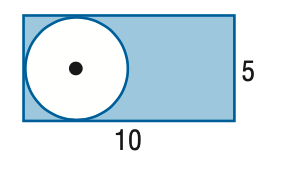

In [ ]:
# Xem cấu trúc mẫu đầu tiên
print(train_dataset[0]["messages"][0]["content"][0]["text"]) # Câu hỏi
print(train_dataset[0]["messages"][1]["content"][0]["text"]) # Lời giải CoT mẫu
train_dataset[0]["messages"][0]["content"][1]["image"]        # Hiển thị ảnh

Let's first see before we do any finetuning what the model outputs for the first example!

In [ ]:
FastVisionModel.for_inference(model)

# Lấy thử 1 bài toán từ tập test độc lập
test_sample = eval_dataset[1]["messages"]
test_image = test_sample[0]["content"][1]["image"]
test_prompt = test_sample[0]["content"][0]["text"]

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": test_prompt}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
inputs = tokenizer(
    test_image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt"
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt=True)

print("--- KẾT QUẢ MÔ HÌNH GỐC (CHƯA FINE-TUNE) ---")
_ = model.generate(**inputs, streamer=text_streamer, max_new_tokens=3072,
                   use_cache=True, temperature=0.2)

--- KẾT QUẢ MÔ HÌNH GỐC (CHƯA FINE-TUNE) ---
The user wants me to find the area of the shaded region.

**1. Analyze the image:**
*   There is a large triangle.
*   Inside the triangle, there is a circle.
*   The circle is tangent to all three sides of the triangle. This means the circle is the *incircle* of the triangle.
*   The shaded region is the area of the triangle minus the area of the circle.
*   The image shows a radius of the circle. The pink line goes from the center to the edge. The label says "3 in.". So, the radius ($r$) is 3 inches.
*   The problem statement says "Assume that all polygons that appear to be regular are regular." This implies the triangle is an equilateral triangle.

**2. Formulate a plan:**
*   **Step 1:** Calculate the area of the circle.
    *   Formula: $A_{circle} = \pi \cdot r^2$
    *   Given $r = 3$.
*   **Step 2:** Calculate the area of the equilateral triangle.
    *   I need to find the side length ($s$) of the triangle.
    *   The radius ($r$) 

In [ ]:
test_sample = eval_dataset[0]["messages"]
test_sample

[{'role': 'user',
  'content': [{'type': 'text', 'text': '<image>Find x.'},
   {'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=297x285>}]},
 {'role': 'assistant',
  'content': [{'type': 'text',
    'text': '<think>\nDựa vào hình vẽ, ta tiến hành phân tích và lập luận các bước như sau:\n\n1. **Quan sát tam giác phía bên phải:**\n   - Tam giác này là một tam giác vuông (có ký hiệu góc vuông ở đỉnh bên phải).\n   - Cạnh đối diện với góc vuông là cạnh chung thẳng đứng, do đó cạnh này chính là **cạnh huyền** của tam giác vuông và có độ dài bằng $18$.\n   - Một góc nhọn ở đỉnh phía dưới được cho bằng $45^\\circ$.\n   - Cạnh có độ dài $x$ là cạnh kề với góc $45^\\circ$ (nối từ đỉnh góc $45^\\circ$ đến đỉnh góc vuông).\n\n2. **Áp dụng tỉ số lượng giác trong tam giác vuông:**\n   - Trong tam giác vuông, ta có hệ thức giữa cạnh kề, cạnh huyền và góc nhọn:\n     $$\\cos(45^\\circ) = \\frac{\\text{cạnh kề}}{\\text{cạnh huyền}} = \\frac{x}{18}$$\n\n3. **Tính giá trị của $x$:**\n   -

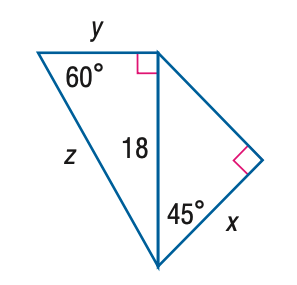

In [ ]:
test_image

In [ ]:
test_prompt

'<image>Find x.'

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support `DPOTrainer` and `GRPOTrainer` for reinforcement learning!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [9]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Chuyển mô hình sang chế độ huấn luyện!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,         # Đánh giá trên tập test độc lập
    args = SFTConfig(
        # --- CẤU HÌNH BỘ NHỚ AN TOÀN CHO GPU T4 ---
        per_device_train_batch_size = 1, # 1 ảnh mỗi lượt nạp để tránh tràn VRAM
        gradient_accumulation_steps = 8, # Tích lũy 8 lượt -> Tổng batch vẫn = 8
        max_length = 1536,               # Đủ cho lời giải CoT mà không tốn RAM
        # ------------------------------------------

        warmup_steps = 10,
        num_train_epochs = 2,            # Chạy thử nghiệm 1 epoch (khoảng 237 steps)
        learning_rate = 2e-4,
        logging_steps = 5,               # Cứ 5 steps in log 1 lần
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "cosine",
        seed = 3407,
        report_to = "none",

        # --- LƯU ĐỊNH KỲ ĐỂ RESUME KHI BỊ LỖI ---
        save_strategy = "steps",
        save_steps = 40,                 # Cứ 40 steps lưu 1 checkpoint
        save_total_limit = 2,            # Chỉ giữ 2 checkpoint gần nhất để đỡ đầy đĩa
        output_dir = "outputs_sft",
        # ----------------------------------------

        # --- ĐO VALIDATION LOSS CHO BÁO CÁO ---
        eval_strategy = "steps",
        eval_steps = 40,                 # Đo trên tập eval_dataset sau mỗi 40 steps
        # --------------------------------------

        # Các tham số bắt buộc cho Vision Finetuning của Unsloth:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
    ),
)

Unsloth: Model does not have a default image size - using 512
Unsloth: Switching to float32 training since model cannot work with float16


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
10.523 GB of memory reserved.


### Tiến hành train mô hình

In [ ]:
trainer_stats = trainer.train() # muon train tiep thi them tham so " resume_from_checkpoint = True "

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,890 | Num Epochs = 2 | Total steps = 474
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 77,512,704 of 4,616,778,240 (1.68% trained)


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss


### Lưu file checkpoint để lần sau train tiếp

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

source_path= '/content/outputs_sft'
destination_path = '/content/drive/MyDrive/outputs_sft'
!cp -r $source_path $destination_path

print("Đã sao lưu toàn bộ checkpoint sang Google Drive thành công!")

MessageError: Error: credential propagation was unsuccessful

### Resume

In [ ]:
# Chỉ định chính xác checkpoint gần nhất bạn đã lưu trên Drive (ví dụ checkpoint-120 hoặc checkpoint-80)
checkpoint_path = "/content/drive/MyDrive/outputs_sft/checkpoint-160"

# Hệ thống sẽ khôi phục toàn bộ trọng số, optimizer, learning rate và train tiếp
trainer_stats = trainer.train(resume_from_checkpoint = checkpoint_path)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,890 | Num Epochs = 1 | Total steps = 237
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 38,756,352 of 4,578,021,888 (0.85% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
200,0.349896,0.356461


Unsloth: Restored added_tokens_decoder metadata in outputs_sft/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_sft/checkpoint-237/tokenizer_config.json.


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

NameError: name 'start_gpu_memory' is not defined

<a name="Inference"></a>
### Inference
Test liền model vừa train (lưu ý bước này chỉ chạy sau khi thực hiện train model)

Nếu ở session mới thì buộc phải chạy code của phần Save Lora để nạp Lora vào

We use `min_p = 0.1` and `temperature = 1.5`. Read this [Tweet](https://x.com/menhguin/status/1826132708508213629) for more information on why.

In [ ]:
import io
from PIL import Image
from transformers import TextStreamer

# Kích hoạt chế độ suy luận nhanh
FastVisionModel.for_inference(model)

# Lấy 1 bài toán từ tập test độc lập
sample_idx = 1
sample = eval_dataset[sample_idx]["messages"]

user_content = sample[0]["content"]
problem_text = next(item["text"] for item in user_content if item["type"] == "text")
test_image   = next(item["image"] for item in user_content if item["type"] == "image")
ground_truth = sample[1]["content"][0]["text"]

if isinstance(test_image, dict):
    if "bytes" in test_image and test_image["bytes"] is not None:
        test_image = Image.open(io.BytesIO(test_image["bytes"]))
    elif "path" in test_image and test_image["path"] is not None:
        test_image = Image.open(test_image["path"])

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": problem_text}
        ]
    }
]

input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
inputs = tokenizer(
    test_image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt"
).to("cuda")

print("=" * 60)
print(f"BÀI TOÁN THỬ NGHIỆM (Index: {sample_idx}):\n{problem_text}")
print("=" * 60)
print("MÔ HÌNH BẮT ĐẦU GIẢI TOÁN:")

text_streamer = TextStreamer(tokenizer, skip_prompt=True)
_ = model.generate(
    **inputs,
    streamer=text_streamer,
    max_new_tokens=1536,
    use_cache=True,
    temperature=0.2,
    top_p=0.95,
)

print("\n" + "=" * 60)
print(f"ĐÁP ÁN GỐC:\n{ground_truth}")
print("=" * 60)

BÀI TOÁN THỬ NGHIỆM (Index: 1):
<image>Find the area of the shaded region. Assume that all polygons that appear to be regular are regular. Round to the nearest tenth.
MÔ HÌNH BẮT ĐẦU GIẢI TOÁN:
Dưới đây là các bước phân tích và giải chi tiết:

1. **Phân tích hình vẽ:**
   - Hình vẽ gồm một hình tròn màu trắng và một hình tam giác màu xanh dương bao quanh nó.
   - Đường tròn nội tiếp tam giác (touching ba cạnh của tam giác) có bán kính $r = 3\text{ in.}$ (được biểu thị bởi đoạn thẳng màu hồng nối từ tâm đến một điểm tiếp xúc trên cạnh).
   - Hình cần tính diện tích là phần màu xanh dương nằm giữa tam giác và đường tròn.
   - Do tam giác được bao quanh hoàn toàn bởi đường tròn nội tiếp và có các cạnh tiếp xúc với đường tròn, ta có:
     $$\text{Diện tích hình tròn} = \text{Diện tích tam giác} - \text{Diện tích hình tròn}$$
     hay:
     $$\text{Diện tích hình màu xanh} = \text{Diện tích tam giác} - \text{Diện tích hình tròn}$$

2. **Tính diện tích hình tròn:**
   - Bán kính của hình trò

<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

Lệnh này chỉ lưu các trọng số LoRA mới học (dung lượng rất nhẹ, chỉ khoảng 50MB – 150MB) chứ không lưu toàn bộ 4 tỷ tham số của mô hình gốc. File này chính là checkpoint "ấm" (Warm-start) để bạn mang sang nạp vào Notebook GRPO (RL) ở giai đoạn sau.

### Lưu drive file lora đã train

In [ ]:
# Tùy chọn: Lưu thẳng vào Drive để không bao giờ mất
# from google.colab import drive
# drive.mount('/content/drive')
model.save_pretrained("/content/drive/MyDrive/qwen3_5_4B_geometry_sft_lora")
tokenizer.save_pretrained("/content/drive/MyDrive/qwen3_5_4B_geometry_sft_lora")
print("Đã lưu an toàn vào Google Drive!")

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/qwen3_5_4B_geometry_sft_lora/tokenizer_config.json.


Đã lưu an toàn vào Google Drive!


Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:


Giải thích thêm:

Khi bạn chạy lệnh

`model.save_pretrained("qwen_geometry_sft_lora")`

Unsloth chỉ lưu phần trọng số thích ứng LoRA (dung lượng chỉ khoảng 50MB – 150MB), bao gồm các file cốt lõi:   
- adapter_model.safetensors: Chứa các ma trận LoRA rank $r=16$ vừa được huấn luyện.   

- adapter_config.json: File cấu hình chỉ đường. Bên trong file này có một dòng quan trọng:

  `"base_model_name_or_path": "unsloth/Qwen3.5-4B"`

- Các file cấu hình của tokenizer.   

=> Thư mục này hoàn toàn không chứa 4 tỷ tham số của mô hình Qwen gốc.


Quá trình from_pretrained("qwen_geometry_sft_lora") diễn ra như thế nào?

Khi bạn đặt RELOAD_FROM_DISK = True và gọi lệnh trên, thư viện sẽ tự động thực hiện 2 bước ngầm:   

1. Đọc file cấu hình: Unsloth đọc file adapter_config.json và thấy bạn dùng mô hình nền là unsloth/Qwen3.5-4B. Nó sẽ nạp mô hình nền gốc đó lên GPU (ở dạng lượng tử hóa 4-bit).   
2. Gắn LoRA lên trên: Sau khi mô hình gốc đã nạp xong vào VRAM, Unsloth bốc các ma trận LoRA từ adapter_model.safetensors gắn đè lên các tầng Attention và MLP tương ứng.   

In [ ]:
import io
from PIL import Image
from transformers import TextStreamer

# 1. Đổi thành True nếu bạn mở session mới và muốn nạp lại LoRA từ đĩa
RELOAD_FROM_DISK = True

if RELOAD_FROM_DISK:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "/content/drive/MyDrive/qwen3_5_4B_geometry_sft_lora", # Trỏ đúng thư mục đã lưu ở Cell 1
        load_in_4bit = True,
    )

# Kích hoạt chế độ suy luận nhanh
FastVisionModel.for_inference(model)

# 2. Lấy 1 bài toán hình học từ tập test độc lập để kiểm chứng
sample = eval_dataset[0]["messages"]
user_content = sample[0]["content"]

test_prompt = next(item["text"] for item in user_content if item["type"] == "text")
test_image  = next(item["image"] for item in user_content if item["type"] == "image")

# Giải nén an toàn nếu ảnh ở dạng dict/bytes
if isinstance(test_image, dict):
    if "bytes" in test_image and test_image["bytes"] is not None:
        test_image = Image.open(io.BytesIO(test_image["bytes"]))
    elif "path" in test_image and test_image["path"] is not None:
        test_image = Image.open(test_image["path"])

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": test_prompt}
        ]
    }
]

input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    test_image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

# 3. Sinh chuỗi giải toán từng bước
text_streamer = TextStreamer(tokenizer, skip_prompt = True)

print("=" * 60)
print(f"ĐỀ BÀI: {test_prompt}")
print("=" * 60)
print("MÔ HÌNH ĐÃ SFT BẮT ĐẦU GIẢI:")

_ = model.generate(
    **inputs,
    streamer = text_streamer,
    max_new_tokens = 1536,  # Đủ dài để viết CoT và \boxed{}
    use_cache = True,
    temperature = 0.2,      # Giảm về 0.2 để tính toán chặt chẽ, không bị ảo giác
    top_p = 0.95
)

==((====))==  Unsloth 2026.10.1: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

ĐỀ BÀI: <image>Find x.
MÔ HÌNH ĐÃ SFT BẮT ĐẦU GIẢI:
Dựa vào hình vẽ, ta có các thông tin hình học sau:
1. Tam giác phía trên là một tam giác vuông (có ký hiệu góc vuông màu hồng).
   - Góc nhọn ở đỉnh phía trên bên trái có số đo là $60^\circ$.
   - Cạnh đối diện với góc $60^\circ$ có độ dài là $18$.
   - Cạnh kề với góc $60^\circ$ có độ dài là $y$.
   - Cạnh huyền có độ dài là $z$.

2. Tam giác phía dưới có góc nhọn bằng $45^\circ$ và cạnh đối diện với góc $45^\circ$ có độ dài là $x$.

Để tìm độ dài của cạnh $x$, ta thực hiện các bước sau:

**Bước 1: Tính độ dài cạnh $y$**
Xét tam giác vuông phía trên, áp dụng tỉ số lượng giác trong tam giác vuông:
$$\cos(60^\circ) = \frac{\text{cạnh kề}}{\text{cạnh huyền}} = \frac{y}{z}$$
$$\sin(60^\circ) = \frac{\text{cạnh đối}}{\text{cạnh huyền}} = \frac{18}{z}$$

Từ hai tỉ số trên, ta có:
$$\tan(60^\circ) = \frac{\text{cạnh đối}}{\text{cạnh kề}} = \frac{18}{y}$$

Suy ra:
$$y = \frac{18}{\tan(60^\circ)} = \frac{18}{\sqrt{3}} = \frac{18\sqrt{3}}{3} =

### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens. See [our docs](https://unsloth.ai/docs/basics/inference-and-deployment) for more deployment options.

- float32 (FP32 - 32 bit = 4 byte): Độ chính xác tiêu chuẩn cũ, rất nét nhưng tốn bộ nhớ gấp đôi. Mô hình 4B tham số sẽ nặng khoảng 16 GB.

- float16 (FP16 - 16 bit = 2 byte): Chuẩn phổ biến nhất hiện nay cho các mô hình AI. Dung lượng giảm một nửa nhưng giữ nguyên gần như 100% độ chính xác. Mô hình 4B tham số sẽ nặng khoảng 8 GB.

- 4-bit (QLoRA bạn đang train): Nén tối đa xuống còn 4 bit (0.5 byte) mỗi trọng số để nhét vừa vào GPU T4 của Colab. Mô hình 4B chỉ tốn khoảng 4.5 GB VRAM.

Unsloth mới cộng toán học trực tiếp ma trận LoRA vào ma trận gốc ($W_{new} = W_{base} + \Delta W$) và xuất ra một thư mục nặng khoảng 8GB – 9GB chứa toàn bộ mô hình đã hợp nhất.

## KHÔNG NÊN CHẠY BƯỚC NÀY TRÊN GOOGLE COLAB MIỄN PHÍ.

- Dễ sập RAM: Quá trình giải nén 4-bit và hợp nhất ma trận sang 16-bit ngốn từ 14GB đến 18GB System RAM, rất dễ khiến máy ảo Colab (chỉ có 12.7GB RAM) bị tràn bộ nhớ và văng kernel.

- Tốn dung lượng: File sau khi lưu nặng tới hơn 8GB, rất lâu để tải về máy hoặc lưu vào Google Drive.   

- Không cần thiết cho giai đoạn tiếp theo: Khi bạn chuyển sang làm Học tăng cường (RL / GRPO) ở Notebook 2, Unsloth hỗ trợ nạp thẳng thư mục adapter LoRA nhỏ gọn (qwen_geometry_sft_lora nặng ~100MB) mà không bắt buộc bạn phải gộp sang float16

In [ ]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
model.save_pretrained_merged("/content/drive/MyDrive/my_models/unsloth_finetune", tokenizer,save_method="merged_16bit")

# To export and save to your Hugging Face account
# if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "YOUR_HF_TOKEN")

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/my_models/unsloth_finetune/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...




Unsloth: Copying 2 files from cache to `/content/drive/MyDrive/my_models/unsloth_finetune`:   0%|          | 0/2 [00:00<?, ?it/s]

Unsloth: Copying 2 files from cache to `/content/drive/MyDrive/my_models/unsloth_finetune`:  50%|█████     | 1/2 [03:06<03:06, 186.05s/it]


KeyboardInterrupt: 

### GGUF / llama.cpp Conversion
To save to `GGUF` / `llama.cpp`, we support it natively now! We clone `llama.cpp` and we default save it to `q8_0`. We allow all methods like `q4_k_m`. Use `save_pretrained_gguf` for local saving and `push_to_hub_gguf` for uploading to HF.

Some supported quant methods (full list on our [docs page](https://unsloth.ai/docs/basics/inference-and-deployment/saving-to-gguf)):
* `q8_0` - Fast conversion. High resource use, but generally acceptable.
* `q4_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q4_K.
* `q5_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q5_K.

[**NEW**] To finetune and auto export to Ollama, try our [Ollama notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)

In [ ]:
# Save to 8bit Q8_0
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer,)
# Remember to go to https://huggingface.co/settings/tokens for a token!
# And change hf to your username!
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, token = "YOUR_HF_TOKEN")

# Save to 16bit GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "f16")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "f16", token = "YOUR_HF_TOKEN")

# Save to q4_k_m GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "q4_k_m")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "q4_k_m", token = "YOUR_HF_TOKEN")

# Save to multiple GGUF options - much faster if you want multiple!
if False:
    model.push_to_hub_gguf(
        "HF_USERNAME/qwen_finetune", # Change hf to your username!
        tokenizer,
        quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
        token = "YOUR_HF_TOKEN",
    )